In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA'
)
ds

DataStore has 3413 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'clusters_coarse', 
            'RNA_nCounts', 'RNA_cell_cycle_phase', 'RNA_nFeatures', 'RNA_cluster', 'G2M_score', 
            'RNA_G2M_score', 'RNA_S_score', 'RNA_UMAP2', 'RNA_percentRibo', 'clusters', 
            'S_score', 'RNA_UMAP1'
   RNA assay has 12497 (27998) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'highly_variable_genes', 
            'dropOuts', 'I__hvgs'

In [3]:
ds.cells.to_pandas_dataframe(
    ['clusters'],
    key='I'
)['clusters'].value_counts()

clusters
Ductal           733
Ngn3 high EP     624
Pre-endocrine    585
Beta             573
Alpha            454
Ngn3 low EP      233
Epsilon          141
Delta             70
Name: count, dtype: int64

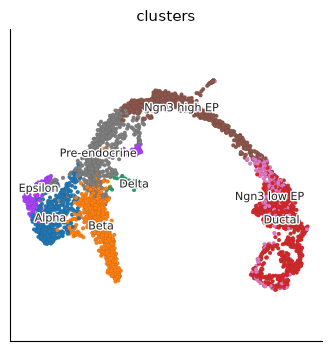

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
    legend_loc='on_data',
)

In [5]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='clusters',
    sources=['Ductal'],
    sinks=['Alpha', 'Beta', 'Delta'],
)

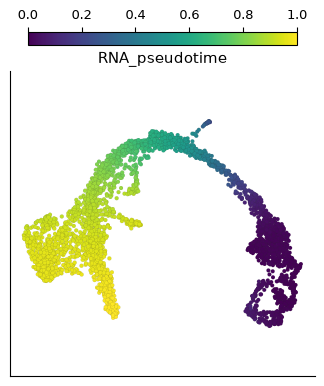

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
)

In [7]:
markers = ds.run_pseudotime_marker_search(
    cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
)

In [8]:
markers.table.head()

,feature_index,feature_name,r_value,p_value
0,6,Mrpl15,-0.080615,2.410271e-06
1,14,Vcpip1,0.019255,2.607735e-01
2,15,Snhg6,-0.249382,1.505228e-49
3,16,Tcf24,-0.003737,8.272468e-01
4,17,Ppp1r42,-0.031778,6.341229e-02


In [9]:
markers.table.sort_values('r_value')[:15]

,feature_index,feature_name,r_value,p_value
8853,18864,Spp1,-0.841547,0.0
10280,22385,Rps19,-0.820144,0.0
11328,24581,Rpl13,-0.817231,0.0
7640,16254,Rps8,-0.798183,0.0
172,431,Dbi,-0.794341,0.0
9305,19815,Rpl32,-0.787505,0.0
12187,26498,Rps4x,-0.782475,0.0
1409,3163,Sparc,-0.769434,0.0
6445,13425,Rpl12,-0.758052,0.0
9683,20787,Mgst1,-0.750851,0.0


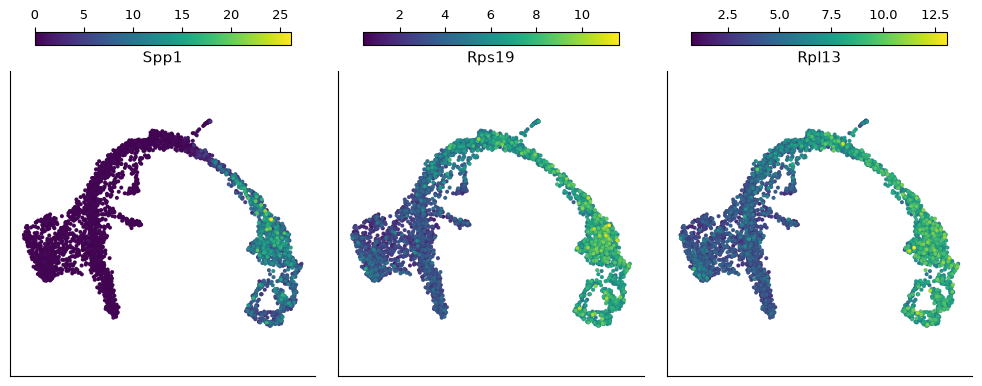

In [10]:
neg_genes = (
    markers.table.sort_values('r_value')['feature_name']
    .head(3)
    .tolist()
)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=neg_genes,
    sort_values=True,
)

In [11]:
markers.table.sort_values('r_value', ascending=False)[:10]

,feature_index,feature_name,r_value,p_value
6809,14296,Gnas,0.720882,0.000000e+00
10760,23549,Cpe,0.712643,0.000000e+00
9838,21244,Aplp1,0.706891,0.000000e+00
1415,3186,Fam183b,0.655091,0.000000e+00
11580,25060,Hmgn3,0.615789,0.000000e+00
3859,8171,Tuba1a,0.607351,0.000000e+00
12219,26573,Bex2,0.606419,0.000000e+00
12290,26730,Pcsk1n,0.604460,0.000000e+00
942,2189,Rap1b,0.583327,1.983113e-310
2804,5837,Scgn,0.582420,3.057720e-309


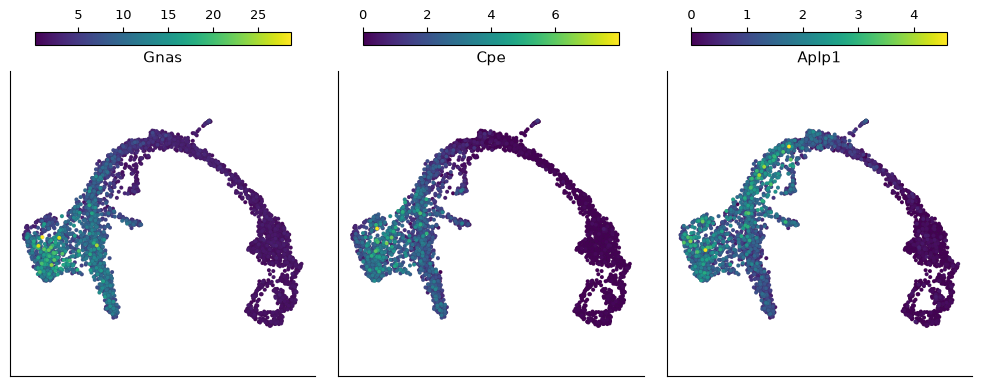

In [12]:
pos_genes = (
    markers.table.sort_values('r_value', ascending=False)['feature_name']
    .head(3)
    .tolist()
)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pos_genes,
    sort_values=True,
)